# Lab Assignment: Generative AI

#### Lab team: teamCode

##### Name (member 1): Sara Echeverribar Lalaguna

##### Name (member 2): Raquel Vallejo Rincón

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited.
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip`
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file).

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456
2. TODO: Include references in alphabetical order

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


In [ ]:
#!pip install torch torchvision matplotlib numpy tqdm scipy

## Exercise 1:  Generative AI based on diffusion models: Brownian motion

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t)
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
2. What is the SDE for the time-reversed process?
3. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?


Let the forward diffusion process be

$$
d\mathbf{x}(t)=\sigma^t d\mathbf{W}(t),
\qquad
\mathbf{x}(0)\sim p_0(\mathbf{x}),
\qquad
\sigma>0.
$$

---

### 1. Distribution of $\mathbf{x}(t)$

This process is a Brownian motion with time-dependent diffusion coefficient

$$
g(t)=\sigma^t.
$$

Since the drift term is zero, the solution conditioned on $\mathbf{x}(0)=\mathbf{x}_0$ is

$$
\mathbf{x}(t)
=
\mathbf{x}_0
+
\int_0^t \sigma^s d\mathbf{W}(s).
$$

The stochastic integral is Gaussian with zero mean and covariance

$$
\left(
\int_0^t \sigma^{2s}ds
\right)\mathbf{I}.
$$

Therefore,

$$
\mathbf{x}(t)\mid \mathbf{x}(0)=\mathbf{x}_0
\sim
\mathcal{N}
\left(
\mathbf{x}_0,
\sigma_t^2\mathbf{I}
\right),
$$

where

$$
\sigma_t^2
=
\int_0^t \sigma^{2s}ds
=
\frac{\sigma^{2t}-1}{2\log \sigma}.
$$

Equivalently,

$$
\mathbf{x}(t)
=
\mathbf{x}_0
+
\sigma_t\mathbf{z},
\qquad
\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

This is a variance exploding diffusion process, since the variance increases with time.

---

### 2. Reverse-time SDE

For a general forward SDE,

$$
d\mathbf{x}(t)
=
\mathbf{f}(\mathbf{x},t)dt
+
g(t)d\mathbf{W}(t),
$$

the reverse-time SDE is

$$
d\mathbf{x}(t)
=
\left[
\mathbf{f}(\mathbf{x},t)
-
g(t)^2\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right]dt
+
g(t)d\bar{\mathbf{W}}(t).
$$

In our case,

$$
\mathbf{f}(\mathbf{x},t)=0,
\qquad
g(t)=\sigma^t,
$$

so

$$
d\mathbf{x}(t)
=
-\sigma^{2t}\nabla_{\mathbf{x}}\log p_t(\mathbf{x})dt
+
\sigma^t d\bar{\mathbf{W}}(t).
$$

In practice, the score is approximated by a neural network

$$
\mathbf{s}_\theta(\mathbf{x},t)
\approx
\nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

---

### 3. Image synthesis

- The reverse SDE is integrated **backwards in time**, from $T$ to a small value $\varepsilon$:

$$
t \in [T, \varepsilon], \quad \text{typically } T=1, \ \varepsilon=10^{-3}.
$$

- The initial condition is sampled from

$$
\pi(\mathbf{x})
\approx
p_T(\mathbf{x})
\approx
\mathcal{N}
\left(
\mathbf{0},
\sigma_T^2\mathbf{I}
\right).
$$

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   
3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.
4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.


The model is trained to approximate the time-dependent score

$$
\mathbf{s}_\theta(\mathbf{x}(t),t)
\approx
\nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

Directly learning this quantity is difficult because $p_t(\mathbf{x})$ is unknown. However, for the Brownian motion diffusion process, the conditional perturbation kernel is known:

$$
\mathbf{x}(t)
=
\mathbf{x}(0)
+
\sigma_t\mathbf{z},
\qquad
\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

Therefore,

$$
p_{0t}(\mathbf{x}(t)\mid \mathbf{x}(0))
=
\mathcal{N}
\left(
\mathbf{x}(0),
\sigma_t^2\mathbf{I}
\right),
$$

and its conditional score is

$$
\nabla_{\mathbf{x}(t)}
\log p_{0t}(\mathbf{x}(t)\mid \mathbf{x}(0))
=
-\frac{\mathbf{x}(t)-\mathbf{x}(0)}{\sigma_t^2}
=
-\frac{\mathbf{z}}{\sigma_t}.
$$

The denoising score matching objective used for training is

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{t,\mathbf{x}(0),\mathbf{z}}
\left[
\left\|
\sigma_t\mathbf{s}_\theta(\mathbf{x}(t),t)
+
\mathbf{z}
\right\|_2^2
\right],
$$

where

$$
t\sim\mathcal{U}(\varepsilon,1),
\qquad
\mathbf{x}(0)\sim p_0(\mathbf{x}),
\qquad
\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

The factor $\sigma_t$ balances the contribution of the different noise levels during training.

The score is modelled with a time-dependent U-Net. The network receives the noisy image $\mathbf{x}(t)$ and the diffusion time $t$ as inputs. Its output has the same shape as the image and represents the estimated score field. The architecture uses convolutional downsampling layers, transposed-convolution upsampling layers, skip connections, group normalization and Swish activations.

The scalar time $t$ is injected into the neural network using Gaussian random Fourier features. A fixed random vector $\mathbf{w}$ is sampled at initialization and the time embedding is

$$
\gamma(t)
=
\left[
\sin(2\pi t\mathbf{w}),
\cos(2\pi t\mathbf{w})
\right].
$$

This embedding is passed through dense layers and added to the convolutional feature maps at different resolutions, allowing the same network to represent a different score function for each noise level.

The actual training was performed in the auxiliary training notebook. In this final notebook, we only verify that the trained checkpoint exists and use it later for generation.

In [ ]:
import numpy as np
import torch
from functools import partial

from score_model import ScoreNet

device = "cuda" if torch.cuda.is_available() else "cpu"
sigma = 25.0

def bm_sigma_t(t, sigma=sigma):
    return torch.sqrt(0.5 * (sigma ** (2 * t) - 1.0) / np.log(sigma))

bm_score_model = torch.nn.DataParallel(
    ScoreNet(marginal_prob_std=partial(bm_sigma_t, sigma=sigma))
).to(device)

bm_checkpoint_path = CHECKPOINTS_DIR / "bm_mnist_digit3_best.pth"

checkpoint = torch.load(bm_checkpoint_path, map_location=device)
bm_score_model.load_state_dict(checkpoint)
bm_score_model.eval()

print("Loaded checkpoint:", bm_checkpoint_path.name)

Loaded checkpoint: bm_mnist_digit3_best.pth


In [ ]:
print("Model loaded and ready to generate samples.")
print("Device:", device)
print("Checkpoint:", bm_checkpoint_path.name)

Model loaded and ready to generate samples.
Device: cuda
Checkpoint: bm_mnist_digit3_best.pth


The training code is implemented in the auxiliary training notebook. To keep this final notebook focused on demonstrations and avoid retraining, we load the checkpoint obtained from that training procedure.

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.


In this section, we use the high-quality Brownian motion score model loaded from the checkpoint `bm_mnist_digit3_best.pth`.

The reverse-time SDE for the Brownian motion diffusion model is

$$
d\mathbf{x}(t)
=
-\sigma^{2t}\mathbf{s}_\theta(\mathbf{x}(t),t)dt
+
\sigma^t d\bar{\mathbf{W}}(t),
$$

where $\mathbf{s}_\theta(\mathbf{x},t)$ is the trained neural network approximation of the score.

The process is initialized from

$$
\mathbf{x}(T)\sim \mathcal{N}(0,\sigma_T^2\mathbf{I}),
$$

and integrated backwards from $T=1$ to $\varepsilon=10^{-3}$ using the Euler-Maruyama integrator.

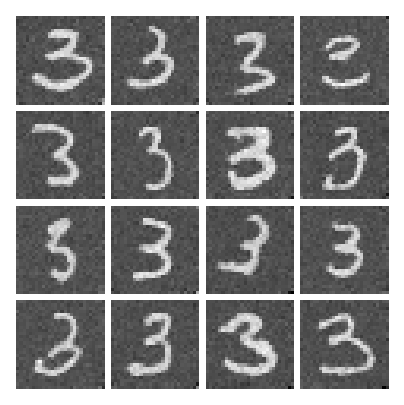

In [ ]:
import diffusion_process as dfp

from diffusion_utilities import plot_image_grid, plot_image_evolution

# Brownian motion diffusion coefficient
bm_diffusion_coefficient = lambda t: sigma ** t

# Reverse-time drift for Brownian motion
def bm_reverse_drift_coefficient(x_t, t):
    return -(bm_diffusion_coefficient(t) ** 2).view(-1, 1, 1, 1) * bm_score_model(x_t, t)

# Initial condition at time T
T = 1.0
eps = 1.0e-3
n_steps = 500
n_images = 16

torch.manual_seed(123)

image_T = bm_sigma_t(torch.ones(n_images, device=device) * T).view(-1, 1, 1, 1) * torch.randn(
    n_images, 1, 28, 28, device=device
)

# Reverse SDE integration with Euler-Maruyama
with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=bm_reverse_drift_coefficient,
        diffusion_coefficient=bm_diffusion_coefficient,
    )

generated_images_bm = synthetic_images_t[..., -1].detach().cpu()

_ = plot_image_grid(
    images=generated_images_bm,
    figsize=(5, 5),
    n_rows=4,
    n_cols=4,
    cmap="gray",
    normalize=True,
)

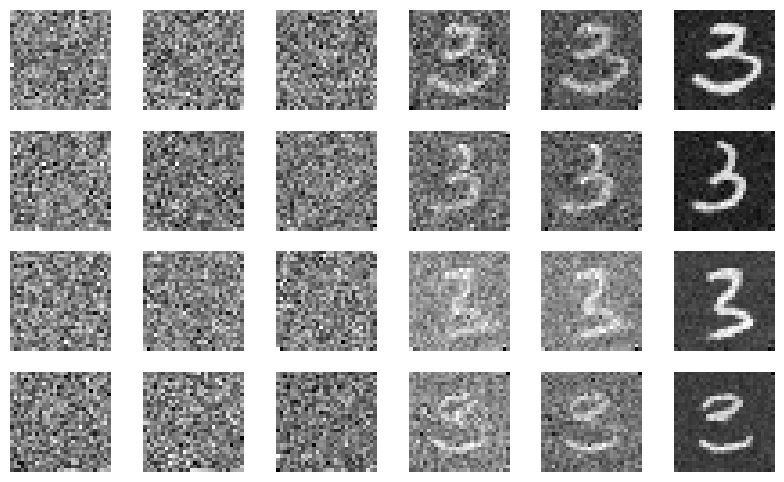

In [ ]:
_ = plot_image_evolution(
    images=synthetic_images_t.detach().cpu(),
    n_images=4,
    n_intermediate_steps=[0, 100, 200, 450, 475, 500],
    figsize=(10, 6),
    cmap="gray",
)

The first figure shows final samples generated by the Brownian motion diffusion model using the Euler-Maruyama reverse sampler. Since the checkpoint was trained on MNIST digit 3, the generated samples are expected to resemble handwritten threes.

The second figure illustrates the reverse diffusion trajectory: the process starts from Gaussian noise at $T=1$ and progressively denoises the samples until reaching realistic digit images near $\varepsilon=10^{-3}$.

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.
2. Explain how the probability flow ODE can be used to generate samples from  $p_0\left(\mathbf{x} \right)$.
2. Implement and illustrate the use of this method to generate synthetic images of handwritten digits.
3. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.


The Fokker-Planck equation describes how the probability density $p_t(\mathbf{x})$ associated with an SDE evolves over time. For a general SDE,

$$
d\mathbf{x}(t)
=
\mathbf{f}(\mathbf{x},t)dt
+
g(t)d\mathbf{W}(t),
$$

the corresponding density satisfies

$$
\frac{\partial p_t(\mathbf{x})}{\partial t}
=
-\nabla_{\mathbf{x}}\cdot
\left(
\mathbf{f}(\mathbf{x},t)p_t(\mathbf{x})
\right)
+
\frac{1}{2}g(t)^2
\Delta_{\mathbf{x}}p_t(\mathbf{x}).
$$

The probability flow ODE is a deterministic process that has the same marginal distributions $p_t(\mathbf{x})$ as the reverse-time SDE:

$$
d\mathbf{x}(t)
=
\left[
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2
\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right]dt.
$$

For the Brownian motion diffusion model,

$$
\mathbf{f}(\mathbf{x},t)=0,
\qquad
g(t)=\sigma^t,
$$

so the probability flow ODE becomes

$$
d\mathbf{x}(t)
=
-\frac{1}{2}\sigma^{2t}
\mathbf{s}_\theta(\mathbf{x}(t),t)dt.
$$

Unlike the Euler-Maruyama sampler, this sampler is deterministic once the initial noise sample is fixed, because it does not include the stochastic Brownian noise term.

The probability flow ODE can also be used to estimate likelihoods because it defines an invertible continuous transformation between data samples $\mathbf{x}(0)$ and latent variables $\mathbf{x}(T)$. For an ODE

$$
\frac{d\mathbf{x}}{dt}
=
\tilde{\mathbf{f}}_\theta(\mathbf{x},t),
$$

the instantaneous change of variables formula is

$$
\frac{d\log p_t(\mathbf{x}(t))}{dt}
=
-
\nabla_{\mathbf{x}}\cdot
\tilde{\mathbf{f}}_\theta(\mathbf{x}(t),t).
$$

Integrating from $0$ to $T$ gives

$$
\log p_0(\mathbf{x}(0))
=
\log p_T(\mathbf{x}(T))
+
\int_0^T
\nabla_{\mathbf{x}}\cdot
\tilde{\mathbf{f}}_\theta(\mathbf{x}(t),t)\,dt.
$$





The terminal density is approximated by the Gaussian prior

$$
p_T(\mathbf{x})
\approx
\mathcal{N}
\left(
\mathbf{0},
\sigma_T^2\mathbf{I}
\right).
$$

Finally, the likelihood can be reported as bits per dimension:

$$
\mathrm{BPD}
=
-
\frac{\log p_0(\mathbf{x})}{D\log 2},
$$

where $D$ is the number of image dimensions.

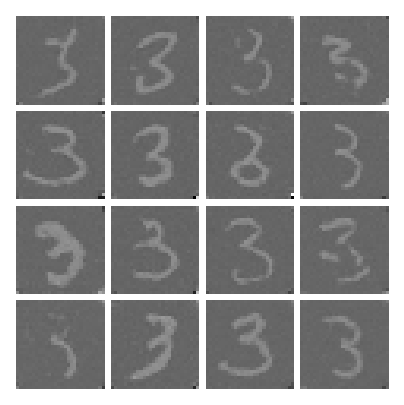

In [ ]:
# Probability flow ODE drift for Brownian motion
def bm_probability_flow_drift(x_t, t):
    return -0.5 * (bm_diffusion_coefficient(t) ** 2).view(-1, 1, 1, 1) * bm_score_model(x_t, t)

# Zero diffusion coefficient because this is an ODE, not an SDE
zero_diffusion_coefficient = lambda t: torch.zeros_like(t)

T = 1.0
eps = 1.0e-3
n_steps = 500
n_images = 16

torch.manual_seed(123)

image_T = bm_sigma_t(torch.ones(n_images, device=device) * T).view(-1, 1, 1, 1) * torch.randn(
    n_images, 1, 28, 28, device=device
)

with torch.no_grad():
    times_ode, synthetic_images_ode_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=bm_probability_flow_drift,
        diffusion_coefficient=zero_diffusion_coefficient,
    )

generated_images_bm_ode = synthetic_images_ode_t[..., -1].detach().cpu()

_ = plot_image_grid(
    images=generated_images_bm_ode,
    figsize=(5, 5),
    n_rows=4,
    n_cols=4,
    cmap="gray",
    normalize=True,
)

The probability flow ODE generates recognizable samples of digit 3 using the same trained Brownian motion score model. Compared with the stochastic Euler-Maruyama sampler, the ODE samples appear smoother and slightly more blurred, which is expected because the stochastic correction term is removed.

## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t) + \sqrt{\beta(t)} d\mathbf{W}(t)
$$
with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
2. What is the SDE for the time-reversed process?
3. For the synthesis of new images
        1. In what interval is the reverse process SDE integrated?
        2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?

Let the forward diffusion process be

$$
d\mathbf{x}(t)
=
-\frac{1}{2}\beta(t)\mathbf{x}(t)dt
+
\sqrt{\beta(t)}d\mathbf{W}(t),
\qquad
\mathbf{x}(0)\sim p_0(\mathbf{x}).
$$

This is a variance preserving diffusion process. Unlike the Brownian motion model, the drift term progressively pulls the data towards zero while the diffusion term injects noise.

---

### 1. Distribution of $\mathbf{x}(t)$

Conditioned on $\mathbf{x}(0)=\mathbf{x}_0$, the solution is Gaussian:

$$
\mathbf{x}(t)\mid \mathbf{x}(0)=\mathbf{x}_0
\sim
\mathcal{N}
\left(
\boldsymbol{\mu}_t(\mathbf{x}_0),
\sigma_t^2\mathbf{I}
\right).
$$

For the Ornstein-Uhlenbeck process,

$$
\boldsymbol{\mu}_t(\mathbf{x}_0)
=
\alpha(t)\mathbf{x}_0,
$$

where

$$
\alpha(t)
=
\exp
\left(
-\frac{1}{2}
\int_0^t \beta(s)ds
\right).
$$

The variance is

$$
\sigma_t^2
=
1-\alpha(t)^2
=
1-
\exp
\left(
-\int_0^t \beta(s)ds
\right).
$$

Therefore,

$$
\mathbf{x}(t)
=
\alpha(t)\mathbf{x}_0
+
\sigma_t\mathbf{z},
\qquad
\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

As $t$ increases, $\alpha(t)$ decreases and $\sigma_t^2$ approaches 1, so the distribution approaches a standard Gaussian distribution.

---

### 2. Reverse-time SDE

For a general forward SDE,

$$
d\mathbf{x}(t)
=
\mathbf{f}(\mathbf{x},t)dt
+
g(t)d\mathbf{W}(t),
$$

the reverse-time SDE is

$$
d\mathbf{x}(t)
=
\left[
\mathbf{f}(\mathbf{x},t)
-
g(t)^2\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right]dt
+
g(t)d\bar{\mathbf{W}}(t).
$$

For the Ornstein-Uhlenbeck process,

$$
\mathbf{f}(\mathbf{x},t)
=
-\frac{1}{2}\beta(t)\mathbf{x},
\qquad
g(t)
=
\sqrt{\beta(t)}.
$$

Thus, the reverse-time SDE is

$$
d\mathbf{x}(t)
=
\left[
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right]dt
+
\sqrt{\beta(t)}d\bar{\mathbf{W}}(t).
$$

In practice, the score is approximated by a neural network:

$$
\mathbf{s}_\theta(\mathbf{x},t)
\approx
\nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

Therefore, the reverse SDE used for generation is

$$
d\mathbf{x}(t)
=
\left[
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)\mathbf{s}_\theta(\mathbf{x}(t),t)
\right]dt
+
\sqrt{\beta(t)}d\bar{\mathbf{W}}(t).
$$

---

### 3. Image synthesis

For image synthesis, the reverse SDE is integrated backwards in time from $T$ to a small value $\varepsilon$ close to zero:

$$
t\in[T,\varepsilon],
\qquad
T=1,
\qquad
\varepsilon=10^{-3}.
$$

The initial condition is sampled from the terminal distribution of the forward process. Since the Ornstein-Uhlenbeck process is variance preserving, this terminal distribution is approximately

$$
\pi(\mathbf{x})
\approx
p_T(\mathbf{x})
\approx
\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.
2. Using the cosine noise schedule.
3. Using a third noise schedule of your choice.


In this section, we compare three Ornstein-Uhlenbeck diffusion models trained with different noise schedules:

- Linear schedule
- Cosine schedule
- Constant schedule

The models were trained in auxiliary scripts. In this notebook, we load the corresponding checkpoints and generate samples using the reverse-time SDE with the Euler-Maruyama integrator.

In [ ]:
import numpy as np
import torch
from functools import partial
from score_model import ScoreNet

def load_ou_model(checkpoint_name, sigma_t_fn):
    model = torch.nn.DataParallel(
        ScoreNet(marginal_prob_std=sigma_t_fn)
    ).to(device)

    checkpoint_path = CHECKPOINTS_DIR / checkpoint_name
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint)
    model.eval()

    print("Loaded:", checkpoint_name)
    return model

In [ ]:
import diffusion_process as dfp
from diffusion_utilities import plot_image_grid

# OU diffusion coefficient
def ou_diffusion_coefficient(beta_fn):
    return lambda t: torch.sqrt(beta_fn(t))

def generate_ou_images(score_model, beta_fn):
    T = 1.0
    eps = 1e-3
    n_steps = 500
    n_images = 16

    def drift(x_t, t):
        beta_t = beta_fn(t).view(-1, 1, 1, 1)
        return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t)

    torch.manual_seed(123)

    image_T = torch.randn(n_images, 1, 28, 28, device=device)

    with torch.no_grad():
        _, x_t = dfp.euler_maruyama_integrator(
            image_T,
            t_0=T,
            t_end=eps,
            n_steps=n_steps,
            drift_coefficient=drift,
            diffusion_coefficient=ou_diffusion_coefficient(beta_fn),
        )

    return x_t[..., -1].cpu()

In [ ]:
beta_min = 0.1
beta_max = 20.0

def beta_linear(t):
    return beta_min + t * (beta_max - beta_min)

def beta_constant(t):
    return 5.0 * torch.ones_like(t)

def beta_cosine(t, s=0.008):
    t = torch.clamp(t, 0.0, 0.999)
    angle = (np.pi / 2) * (t + s) / (1 + s)
    return (np.pi / (1 + s)) * torch.tan(angle)


 Linear
Loaded: ou_mnist_digit3_linear.pth

 Cosine
Loaded: ou_mnist_digit3_cosine.pth

 Constant
Loaded: ou_mnist_digit3_constant.pth


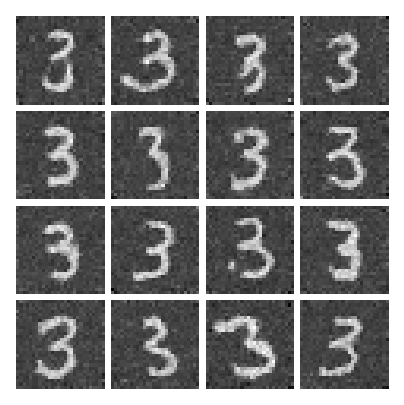

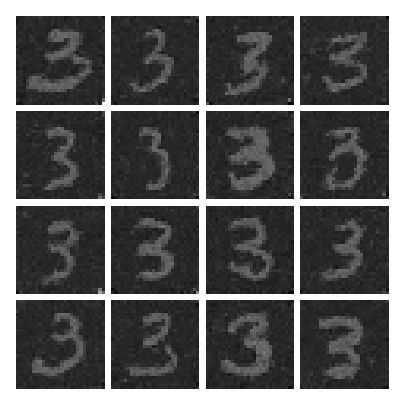

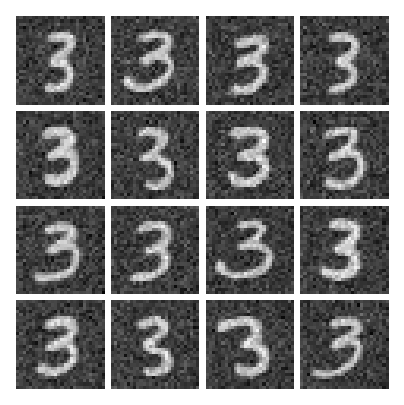

In [ ]:
configs = {
    "Linear": ("ou_mnist_digit3_linear.pth", beta_linear),
    "Cosine": ("ou_mnist_digit3_cosine.pth", beta_cosine),
    "Constant": ("ou_mnist_digit3_constant.pth", beta_constant),
}

for name, (ckpt, beta_fn) in configs.items():
    print("\n", name)

    # sigma_t solo para inicializar la red (no necesitamos exactitud extrema aquí)
    sigma_dummy = lambda t: torch.sqrt(1 - torch.exp(-t))

    model = load_ou_model(ckpt, sigma_dummy)

    images = generate_ou_images(model, beta_fn)

    _ = plot_image_grid(
        images=images,
        figsize=(5, 5),
        n_rows=4,
        n_cols=4,
        cmap="gray",
        normalize=True,
    )

The figures show samples generated with Ornstein-Uhlenbeck diffusion models trained using three different noise schedules: linear, cosine and constant.

All models generate recognizable MNIST digit 3 samples, which confirms that the reverse SDE can successfully transform samples from the Gaussian prior into images from the target distribution.

The linear schedule produces consistent and relatively sharp samples. The cosine schedule also produces recognizable digits, although the samples appear smoother and slightly darker in this run. The constant schedule generates clear threes but with more visible background noise.

Overall, the three schedules are able to generate valid samples, but they lead to differences in sharpness, contrast and residual noise. This illustrates that the choice of noise schedule affects the quality of the generated images.

## Exercise 3:  Evaluation of the quality of the generated images
1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
    1. The negative log-likelihood (NLL).
    2. Bits per dimension (BPD).
    3. Fréchet Inception Distance (FID).
    4. A third measure of your choice.
2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.


In this exercise, we evaluate the quality of the generated samples using likelihood-based and image-quality metrics. The full computations were performed in the auxiliary evaluation notebook. In this final notebook, we summarize the metrics, report the final tables, and discuss the conclusions.

#### Quality metrics

**Negative log-likelihood (NLL)** measures how probable the real data are under the generative model. Lower NLL indicates better likelihood. Its advantage is that it is theoretically well grounded, but for diffusion models it is expensive because it requires probability-flow ODE likelihood estimation.

**Bits per dimension (BPD)** is the normalized version of NLL:

$$
\mathrm{BPD}
=
-
\frac{\log p_0(\mathbf{x})}{D\log 2}.
$$

Lower BPD indicates better likelihood per image dimension. It allows comparing models across datasets or image sizes, but it is computationally expensive and may not always correlate perfectly with visual quality.

**Fréchet Inception Distance (FID)** compares real and generated images in a learned feature space. Lower FID indicates that generated samples are closer to real samples. In this project, we use FID-MNIST, computed with features from a MNIST classifier instead of ImageNet Inception features.

**Inception Score (IS)** measures whether generated images are confidently classified and diverse across classes. Higher IS is usually better. However, in this project most models are trained only on digit 3, so IS is less informative because class diversity is intentionally low.

#### Evaluation results

The following tables summarize the quantitative evaluation of the different diffusion models, noise schedules and sampling strategies.

The full evaluation pipeline (including sample generation, metric computation and BPD estimation) is implemented in the auxiliary notebook:

**03_quality_evaluation.ipynb**

In this final notebook, we only present the final results and discuss the conclusions, in order to avoid repeating the full computational process.

In [14]:
import pandas as pd

df_model_comparison = pd.DataFrame([
    {
        "model_type": "ou",
        "schedule_name": "cosine",
        "sampler": "Euler-Maruyama",
        "FID-MNIST": 46.981548,
        "IS-MNIST": 1.129427,
        "BPD": -5.341077,
    },
    {
        "model_type": "bm",
        "schedule_name": "None",
        "sampler": "Euler-Maruyama",
        "FID-MNIST": 54.261062,
        "IS-MNIST": 1.303574,
        "BPD": -10.503363,
    },
    {
        "model_type": "ou",
        "schedule_name": "linear",
        "sampler": "Euler-Maruyama",
        "FID-MNIST": 121.866725,
        "IS-MNIST": 1.520595,
        "BPD": -0.691975,
    },
    {
        "model_type": "ou",
        "schedule_name": "constant",
        "sampler": "Euler-Maruyama",
        "FID-MNIST": 159.715168,
        "IS-MNIST": 1.243330,
        "BPD": -7.514598,
    },
])

df_model_comparison

,model_type,schedule_name,sampler,FID-MNIST,IS-MNIST,BPD
0,ou,cosine,Euler-Maruyama,46.981548,1.129427,-5.341077
1,bm,None,Euler-Maruyama,54.261062,1.303574,-10.503363
2,ou,linear,Euler-Maruyama,121.866725,1.520595,-0.691975
3,ou,constant,Euler-Maruyama,159.715168,1.243330,-7.514598


The best visual quality according to FID-MNIST is obtained by the OU / VP model with cosine schedule. Although BM / VE obtains a lower BPD, FID-MNIST is more directly related to the perceptual quality of the generated images in this setting. BPD was computed on a small subset because likelihood estimation with the probability-flow ODE is computationally expensive.

In [13]:
df_sampler_comparison = pd.DataFrame([
    {
        "model": "OU / VP cosine",
        "sampler": "predictor_corrector",
        "FID-MNIST": 48.671786,
        "IS-MNIST": 1.201501,
        "BPD": -5.341077,
    },
    {
        "model": "OU / VP cosine",
        "sampler": "euler",
        "FID-MNIST": 58.520205,
        "IS-MNIST": 1.047801,
        "BPD": -5.341077,
    },
    {
        "model": "BM / VE",
        "sampler": "predictor_corrector",
        "FID-MNIST": 71.618907,
        "IS-MNIST": 1.061275,
        "BPD": -10.503363,
    },
    {
        "model": "BM / VE",
        "sampler": "euler",
        "FID-MNIST": 92.668786,
        "IS-MNIST": 1.329152,
        "BPD": -10.503363,
    },
    {
        "model": "BM / VE",
        "sampler": "ode",
        "FID-MNIST": 98.623575,
        "IS-MNIST": 1.381597,
        "BPD": -10.503363,
    },
    {
        "model": "OU / VP cosine",
        "sampler": "ode",
        "FID-MNIST": 389.892118,
        "IS-MNIST": 1.860360,
        "BPD": -5.341077,
    },
])

df_sampler_comparison

,model,sampler,FID-MNIST,IS-MNIST,BPD
0,OU / VP cosine,predictor_corrector,48.671786,1.201501,-5.341077
1,OU / VP cosine,euler,58.520205,1.047801,-5.341077
2,BM / VE,predictor_corrector,71.618907,1.061275,-10.503363
3,BM / VE,euler,92.668786,1.329152,-10.503363
4,BM / VE,ode,98.623575,1.381597,-10.503363
5,OU / VP cosine,ode,389.892118,1.860360,-5.341077


According to the model comparison, the OU / VP model with cosine schedule obtains the best FID-MNIST score. This suggests that the cosine noise schedule produces the best visual samples among the implemented schedules.

In the sampler comparison, predictor-corrector obtains the best FID-MNIST for the OU / VP cosine model, while Euler-Maruyama remains a simpler and competitive alternative. The probability flow ODE gives worse FID-MNIST in this experiment, although it is useful because it enables likelihood and BPD estimation.

Overall, the best configuration in terms of visual quality is:

$$
\textbf{OU / VP + cosine schedule + predictor-corrector sampler}.
$$

If computational simplicity is prioritized, OU / VP with cosine schedule and Euler-Maruyama is also a valid choice.

### References

- Song, Y. et al. (2021). *Score-Based Generative Modeling through Stochastic Differential Equations*. ICLR.

- Nichol, A. Q., & Dhariwal, P. (2021). *Improved Denoising Diffusion Probabilistic Models*. ICML.

- Hyvärinen, A. (2005). *Estimation of Non-Normalized Statistical Models by Score Matching*. JMLR.

- Vincent, P. (2011). *A Connection Between Score Matching and Denoising Autoencoders*. Neural Computation.

- Heusel, M. et al. (2017). *GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium*. NeurIPS.

- LeCun, Y. et al. (1998). *Gradient-Based Learning Applied to Document Recognition*. IEEE.

- Song, Y., & Ermon, S. (2019). *Generative Modeling by Estimating Gradients of the Data Distribution*. NeurIPS.

- Song, Y., & Ermon, S. (2020). *Improved Techniques for Training Score-Based Generative Models*. NeurIPS.

- Guo, Z. et al. (2025). *A Comprehensive Review on Noise Control of Diffusion Model*. arXiv.

- Suárez, A. (2024). *Generative AI for Images – Diffusion Models*. UAM course notes.